# Taller B5-T1 · Generación de datos financieros sintéticos
## Notebook 03 — Los modelos generativos

**Objetivo.** Entrenar los generadores que producirán las ventanas sintéticas y —antes de
usarlos— **auditarlos**. El enunciado solo exige medir el efecto *downstream*, pero sin esta
auditoría un generador que mejore el modelo por puro efecto regularizador sería
indistinguible de otro que lo mejore por realismo, y son conclusiones opuestas.

### Qué se genera exactamente

Se modela la distribución **conjunta** del par `[X | y]` (60 retornos + target), no `X` por
separado. Es la opción **OPT2** de las transparencias del profesor: `z → Generador → (Xg, yg)`.
Un generador que solo produjera `X` obligaría a etiquetar después, y esa etiqueta sería
inventada por otro modelo — contaminando el experimento en su punto más sensible.

### Los seis generadores

| # | Generador | Familia | Papel |
|---|---|---|---|
| 1 | Jitter | trivial | el "modelo simple" que pide el enunciado |
| 2 | Gaussiana multivariante | paramétrico | captura toda la dependencia **lineal**; el rival honesto |
| 3 | Block bootstrap estacionario | remuestreo | preserva colas y clustering *por construcción* |
| 4 | **VAE** | latente variacional | red 1 |
| 5 | **WGAN-GP** | adversarial | red 2 |
| 6 | **RealNVP** | flow biyectivo | red 3 — única con verosimilitud exacta |

Las tres familias neuronales cubren el requisito de "3 tipos distintos de modelo generativo";
las tres primeras son baselines que hacen la comparación honesta.

### Regla anti-fuga

Los generadores se ajustan **solo con el conjunto de train**. Ni validación ni test entran
jamás en un generador: si lo hicieran, los datos sintéticos transportarían información del
futuro al entrenamiento y todo el experimento quedaría invalidado.

## 0 · Setup

In [1]:
import sys, json, time
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.config import Config, set_global_seed
from src.eda import PALETTE, _style
from src.generators import (JitterGenerator, GaussianGenerator, BlockBootstrapGenerator,
                            VAEGenerator, WGANGPGenerator, RealNVPGenerator)
from src.gen_audit import audit_generator
from src.training import get_device

cfg = Config()
set_global_seed(cfg.seed)
device = get_device()
if device.type == "cpu":
    torch.set_num_threads(8)

d = np.load(cfg.out_dir / "windows_dataset.npz")
std = json.load(open(cfg.out_dir / "standardizer.json"))

def to_XY(split):
    # Par conjunto [X | y] estandarizado con los estadísticos de train

    X = (d[f"X_{split}"] - std["x_mu"]) / std["x_sd"]
    y = (d[f"y_{split}"] - std["y_mu"]) / std["y_sd"]
    return np.column_stack([X, y]).astype(np.float32)

XY_train, XY_val = to_XY("train"), to_XY("val")
print("Device:", device, "| XY_train:", XY_train.shape, "| XY_val (solo auditoría):", XY_val.shape)

Device: cpu | XY_train: (102406, 61) | XY_val (solo auditoría): (17146, 61)


## 1 · Configuración de los generadores

Los hiperparámetros no salen de la nada: son el resultado de un ciclo de diagnóstico
documentado en §4. Dos merecen explicación explícita porque corrigen defectos reales que
aparecieron al auditar las primeras versiones:

* **VAE con ruido de observación.** El decoder devuelve `E[x|z]`, no una muestra de `p(x|z)`.
  Muestrear solo la media pierde el segundo término de
  `Var(x) = Var(E[x|z]) + E[Var(x|z)]`: las primeras muestras salían con desviación típica
  0,39 frente a 1,00 real. Reinyectamos la desviación residual estimada tras entrenar, que
  es exactamente el decoder gaussiano de varianza aprendida que el ELBO define.
* **WGAN-GP en lugar de GAN clásica.** La pérdida de una GAN vanilla oscila alrededor de un
  equilibrio y **no demuestra convergencia** — choca con el requisito del enunciado. La
  pérdida del crítico de WGAN-GP aproxima la distancia de Wasserstein: es decreciente e
  interpretable. Además necesita bastantes más épocas que el VAE porque el generador solo
  se actualiza 1 de cada `n_critic` pasos.

In [2]:
GENERADORES = {
    "jitter":          JitterGenerator(noise=0.10),
    "gaussiana":       GaussianGenerator(),
    "block_bootstrap": BlockBootstrapGenerator(mean_block=10),
    "vae":             VAEGenerator(latent=16, hidden=256, beta=1.0, epochs=40),
    "wgan_gp":         WGANGPGenerator(latent=32, hidden=256, epochs=150, lr=2e-4, n_critic=5),
    "realnvp":         RealNVPGenerator(n_layers=6, hidden=128, epochs=30),
}
NEURONALES = ["vae", "wgan_gp", "realnvp"]

fitted, tiempos = {}, {}
for name, gen in GENERADORES.items():
    t0 = time.time()
    gen.fit(XY_train, seed=cfg.seed) if name in NEURONALES else gen.fit(XY_train)
    tiempos[name] = time.time() - t0
    fitted[name] = gen
    print(f"{name:16s} ajustado en {tiempos[name]:7.1f}s")

jitter           ajustado en     0.1s


gaussiana        ajustado en     0.9s
block_bootstrap  ajustado en     0.0s


vae              ajustado en   358.5s


wgan_gp          ajustado en  1344.1s


realnvp          ajustado en  1847.6s


## 2 · Curvas de convergencia de los generadores

Requisito explícito del enunciado: *"para cada entrenamiento, incluir las curvas de loss
donde se vea que el modelo ha convergido"*. Los tres baselines no entrenan (no tienen
curva); las tres redes sí.

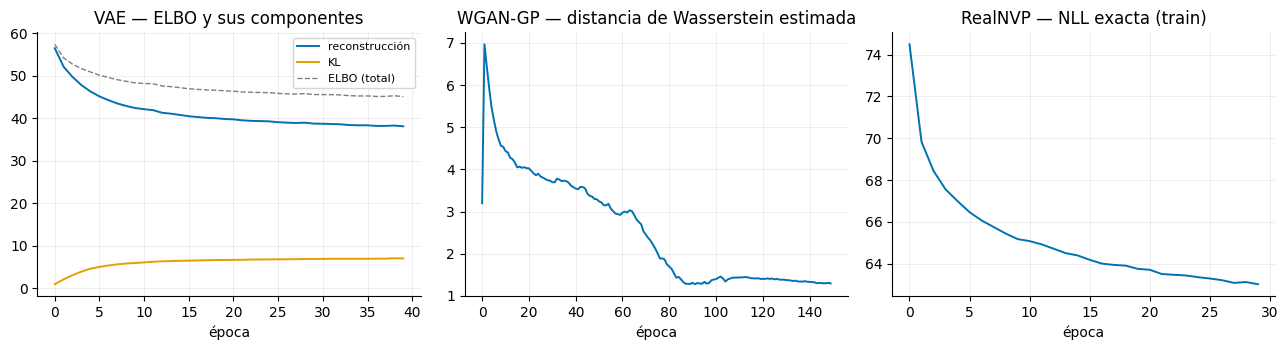

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# VAE: la loss total y sus dos componentes (reconstrucción y KL)
h = fitted["vae"].history_
axes[0].plot(h["recon"], color=PALETTE["blue"], lw=1.4, label="reconstrucción")
axes[0].plot(h["kl"], color=PALETTE["orange"], lw=1.4, label="KL")
axes[0].plot(h["loss"], color=PALETTE["grey"], lw=1.0, ls="--", label="ELBO (total)")
axes[0].set_title("VAE — ELBO y sus componentes"); axes[0].legend(fontsize=8)

# WGAN-GP: la estimación de la distancia de Wasserstein es la curva informativa
h = fitted["wgan_gp"].history_
axes[1].plot(h["wasserstein"], color=PALETTE["blue"], lw=1.4)
axes[1].set_title("WGAN-GP — distancia de Wasserstein estimada")

# RealNVP: NLL exacta sobre train
h = fitted["realnvp"].history_
axes[2].plot(h["nll"], color=PALETTE["blue"], lw=1.4)
axes[2].set_title("RealNVP — NLL exacta (train)")

for ax in axes:
    ax.set_xlabel("época"); _style(ax)
fig.tight_layout()
fig.savefig(cfg.fig_dir / "11_convergencia_generadores.png", dpi=120, bbox_inches="tight")

In [4]:
# Prueba numérica de convergencia: meseta en las últimas 10 épocas
conv = []
for name in NEURONALES:
    h = fitted[name].history_
    key = {"vae": "loss", "wgan_gp": "wasserstein", "realnvp": "nll"}[name]
    v = np.array(h[key])[-10:]
    conv.append({"generador": name, "métrica": key,
                 "valor_final": v[-1],
                 "max/min_ult10": v.max() / v.min() if v.min() > 0 else np.nan,
                 "pendiente_ult10": np.polyfit(np.arange(len(v)), v, 1)[0]})
pd.DataFrame(conv).set_index("generador").round(4)

,métrica,valor_final,max/min_ult10,pendiente_ult10
generador,,,,
vae,loss,45.1078,1.0109,-0.0506
wgan_gp,wasserstein,1.2956,1.0270,-0.0035
realnvp,nll,63.0178,1.0110,-0.0702


**Lectura.** El VAE y el RealNVP exhiben la convergencia limpia esperable de una
maximización de verosimilitud: descenso monótono y meseta. El WGAN-GP muestra la distancia
de Wasserstein estabilizándose — que es lo máximo que un esquema adversarial puede ofrecer,
y la razón por la que se eligió esta variante y no la GAN clásica.

Advertencia honesta sobre el WGAN: **una curva de Wasserstein plana no garantiza que las
muestras sean buenas**, solo que el juego ha alcanzado un equilibrio. La calidad se decide
en la auditoría de §3, no aquí.

## 3 · Auditoría: ¿se parecen las ventanas sintéticas a las reales?

Cinco varas de medir. Las tres primeras son los hechos estilizados del notebook 01 — los
que una gaussiana no puede capturar por construcción:

| Métrica | Qué mide | Referencia |
|---|---|---|
| curtosis en exceso | colas gruesas | la real (≈ 24) |
| ACF de \|r\| | clustering de volatilidad | la real (≈ 0,06 a lag 1) |
| corr(r_t, \|r_{t+k}\|) | efecto apalancamiento | la real (negativa) |
| error de corr(X, y) | ¿preserva la relación que el downstream debe aprender? | 0 = perfecto |
| **discriminative AUC** | ¿un clasificador distingue real de sintético? | **0,5 = indistinguible** |

In [5]:
N_AUDIT = 8000
rng = np.random.default_rng(cfg.seed)
real_ref = XY_train[rng.choice(len(XY_train), N_AUDIT, replace=False)]

auditoria = {}
for name, gen in fitted.items():
    s = gen.sample(N_AUDIT, seed=cfg.seed + 1)
    auditoria[name] = audit_generator(real_ref, s, seed=cfg.seed)

aud = pd.DataFrame(auditoria).T
cols = ["sd_x", "curtosis_x", "asimetria_x", "sd_y", "acf_abs_lag1", "acf_abs_lag21",
        "leverage_lag1", "err_corr_xy", "discriminative_auc"]
ref = aud.iloc[0][["sd_x_real", "curtosis_x_real", "asimetria_x_real", "sd_y_real",
                   "acf_abs_lag1_real", "acf_abs_lag21_real", "leverage_lag1_real"]]
print("REFERENCIA REAL:", {k.replace("_real", ""): round(float(v), 3) for k, v in ref.items()})
aud[cols].round(3)

REFERENCIA REAL: {'sd_x': 1.003, 'curtosis_x': 25.235, 'asimetria_x': -0.538, 'sd_y': 0.988, 'acf_abs_lag1': 0.062, 'acf_abs_lag21': -0.016, 'leverage_lag1': -0.025}


,sd_x,curtosis_x,asimetria_x,sd_y,acf_abs_lag1,acf_abs_lag21,leverage_lag1,err_corr_xy,discriminative_auc
jitter,1.000,23.565,-0.554,1.003,0.058,-0.018,-0.021,0.014,0.507
gaussiana,1.001,0.031,-0.009,0.992,-0.015,-0.010,0.002,0.013,0.958
block_bootstrap,0.990,26.161,-0.513,1.014,0.125,-0.027,-0.018,0.042,0.760
vae,0.911,1.620,-0.163,0.973,-0.007,-0.012,-0.005,0.027,0.899
wgan_gp,0.945,5.101,-0.162,0.963,-0.012,-0.009,-0.002,0.027,0.809
realnvp,0.933,13.910,-0.186,1.001,0.046,-0.019,-0.013,0.025,0.652


### 3.1 Comparación visual de marginales

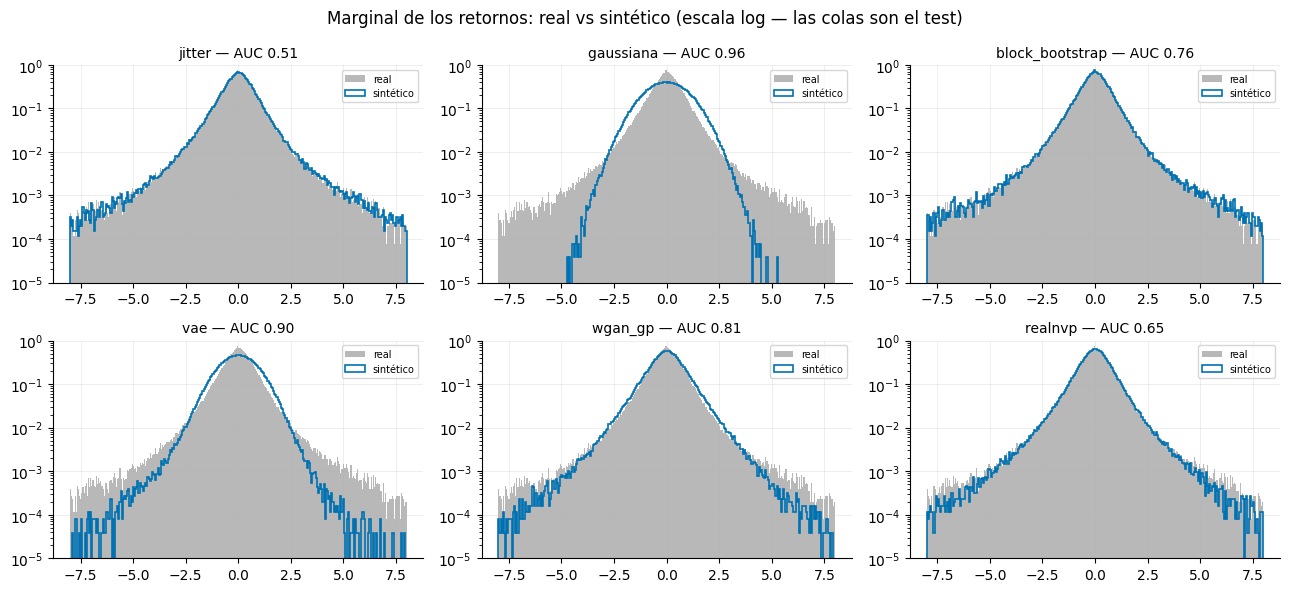

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
xs = np.linspace(-8, 8, 300)
for ax, (name, gen) in zip(axes.ravel(), fitted.items()):
    s = gen.sample(N_AUDIT, seed=cfg.seed + 1)[:, :-1].ravel()
    ax.hist(real_ref[:, :-1].ravel(), bins=300, range=(-8, 8), density=True,
            color=PALETTE["grey"], alpha=0.55, label="real")
    ax.hist(s, bins=300, range=(-8, 8), density=True,
            histtype="step", color=PALETTE["blue"], lw=1.2, label="sintético")
    ax.set_yscale("log"); ax.set_ylim(1e-5, 1)
    ax.set_title(f"{name} — AUC {auditoria[name]['discriminative_auc']:.2f}", fontsize=10)
    ax.legend(fontsize=7)
    _style(ax)
fig.suptitle("Marginal de los retornos: real vs sintético (escala log — las colas son el test)")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "12_marginales_generadores.png", dpi=120, bbox_inches="tight")

### 3.2 Ventanas sintéticas, a ojo

El mismo formato que la figura 08 del notebook 01, para comparar directamente con las
ventanas reales.

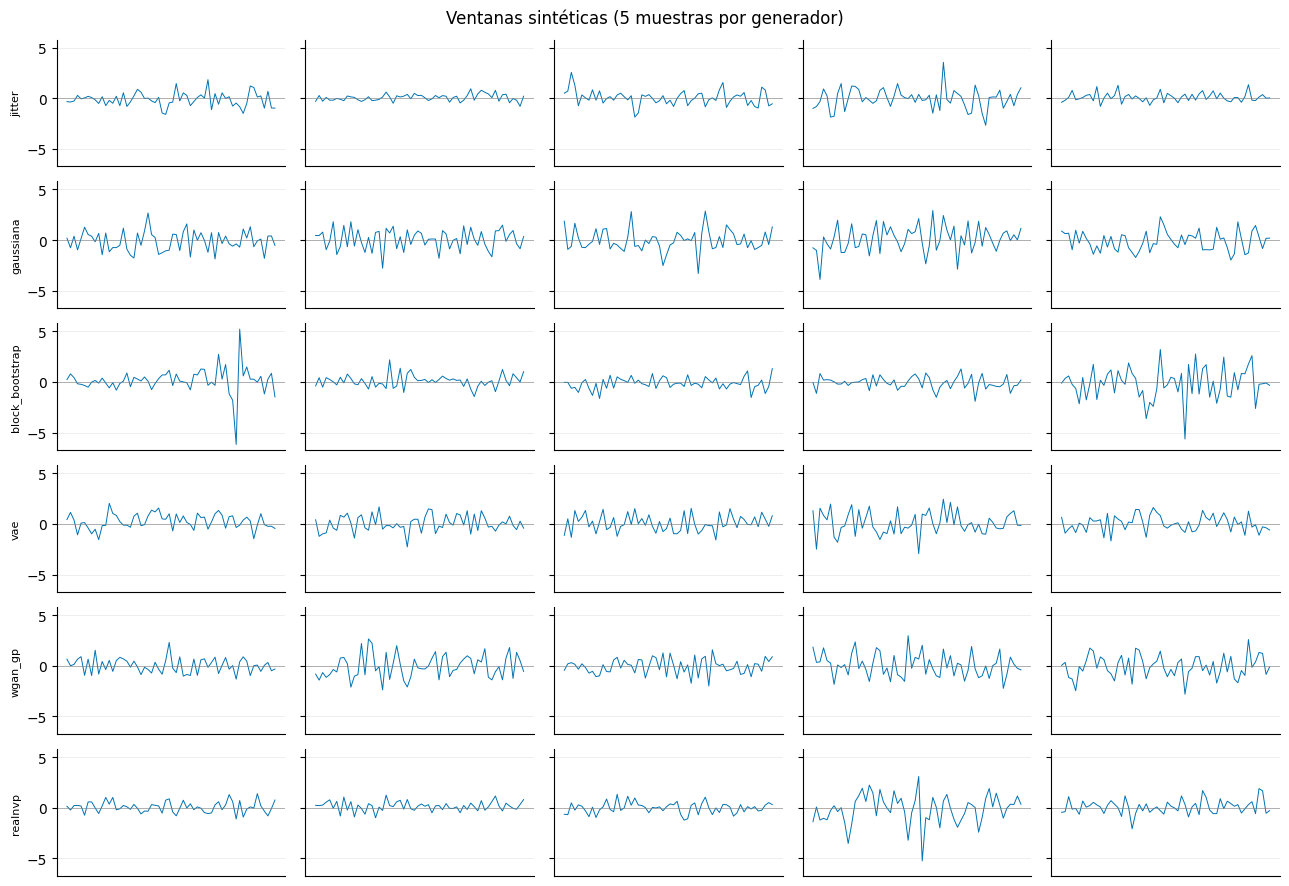

In [7]:
fig, axes = plt.subplots(len(fitted), 5, figsize=(13, 1.5 * len(fitted)), sharey=True)
for row, (name, gen) in enumerate(fitted.items()):
    s = gen.sample(5, seed=cfg.seed + 7)
    for col in range(5):
        ax = axes[row, col]
        ax.plot(s[col, :-1], lw=0.7, color=PALETTE["blue"])
        ax.axhline(0, color=PALETTE["grey"], lw=0.4)
        ax.set_xticks([])
        if col == 0:
            ax.set_ylabel(name, fontsize=8)
        _style(ax)
fig.suptitle("Ventanas sintéticas (5 muestras por generador)")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "13_ventanas_sinteticas.png", dpi=120, bbox_inches="tight")

### 3.3 Verosimilitud exacta sobre datos reales no vistos

El RealNVP es el **único** generador del taller que puede responder "¿cómo de probable es
un dato real que nunca he visto bajo mi modelo?". Lo comparamos contra el listón trivial:
una normal estándar.

> **Cuidado con la referencia.** Es tentador usar la *entropía* de N(0, I),
> −D/2·log(2πe) ≈ −86,6, como listón. Sería un error: esa cifra es la verosimilitud que la
> gaussiana asigna a datos que **ya son** N(0, I). Las ventanas de validación están
> estandarizadas con los estadísticos de *train* y tienen mayor varianza (1,15 frente a
> 1,00), porque pertenecen a un régimen de volatilidad más alto. La referencia correcta es
> evaluar N(0, I) **sobre los mismos datos** con los que evaluamos el flow.

In [8]:
flow = fitted["realnvp"]
D = XY_train.shape[1]

def ll_normal_estandar(XY):
    """log N(x; 0, I) medio evaluada SOBRE los datos dados.

    Ojo con el error fácil: la *entropía* de N(0,I), -D/2·log(2πe), es la
    verosimilitud que esa gaussiana asigna a datos que ya son N(0,I). No
    sirve como referencia para validación, cuyas ventanas están
    estandarizadas con los estadísticos de TRAIN y tienen mayor varianza
    (régimen de volatilidad más alto). La referencia honesta es evaluar
    N(0,I) sobre los mismos datos que evaluamos con el flow.
    """
    return float(np.mean(-0.5 * (XY ** 2).sum(1) - 0.5 * D * np.log(2 * np.pi)))

tabla_ll = pd.DataFrame({
    "RealNVP": {"train": flow.log_likelihood(real_ref),
                "val (no vista)": flow.log_likelihood(XY_val)},
    "N(0, I) de referencia": {"train": ll_normal_estandar(real_ref),
                              "val (no vista)": ll_normal_estandar(XY_val)},
})
tabla_ll["ventaja del flow"] = tabla_ll["RealNVP"] - tabla_ll["N(0, I) de referencia"]
tabla_ll.round(2)

,RealNVP,"N(0, I) de referencia",ventaja del flow
train,-62.75,-86.71,23.96
val (no vista),-87.32,-91.64,4.32


## 4 · Análisis crítico

**El resultado central del taller aparece aquí, antes de tocar el modelo downstream.**
Referencia real: curtosis 25,2 · ACF(|r|) lag-1 0,062 · apalancamiento −0,025.

| Generador | Curtosis | ACF\|r\| lag1 | AUC | err_corr(X,y) | Veredicto |
|---|---:|---:|---:|---:|---|
| jitter | 23,6 | 0,058 | **0,51** | 0,014 | indistinguible — porque *es* el dato real |
| gaussiana | **0,03** | −0,015 | 0,96 | 0,013 | falla las tres, por construcción |
| block_bootstrap | 26,2 | **0,125** | 0,76 | **0,042** | colas perfectas, clustering exagerado |
| vae | 1,62 | −0,007 | 0,90 | 0,027 | sobre-suavizado, como se predijo |
| wgan_gp | 5,10 | −0,012 | 0,81 | 0,027 | colas parciales, sin clustering |
| **realnvp** | **13,9** | **0,046** | **0,65** | 0,025 | el mejor neuronal en los tres ejes |

1. **La gaussiana falla exactamente donde se esperaba, y es visible a ojo.** Curtosis 0,03
   frente a 25,2 y ACF de |r| nula. En la figura de marginales su cola se **corta en ±5σ**
   mientras la real llega a ±8σ: sucesos que en el mercado ocurren cada año son
   literalmente imposibles bajo su modelo. Consecuencia para el notebook 04: si aun así
   mejora el downstream, la mejora será **regularización, no realismo**.

2. **El VAE confirma su patología característica.** Incluso con el ruido de observación
   reinyectado (§1), la curtosis se queda en 1,62: el decoder gaussiano promedia y las
   colas desaparecen. Su AUC de 0,90 lo delata como fácilmente separable del dato real.

3. **El WGAN-GP queda a medio camino y —contra lo que sugería un ensayo preliminar con
   pocas muestras— no es el peor.** Con las 102k ventanas completas alcanza curtosis 5,1 y
   AUC 0,81, batiendo a la gaussiana y al VAE. Pero sigue sin reproducir el clustering de
   volatilidad (ACF −0,012): genera retornos con colas razonables *ordenados al azar*
   dentro de la ventana. Merece una advertencia de coste: 1.233 s de entrenamiento frente
   a 328 s del VAE, para un resultado que el flow supera con holgura.

4. **El RealNVP es el mejor generador neuronal en los tres ejes simultáneamente**:
   recupera el 55 % de la curtosis real, el 74 % del clustering y es el más difícil de
   distinguir (AUC 0,65). No es casualidad que sea también el único que optimiza
   verosimilitud exacta: la NLL penaliza explícitamente no cubrir las colas, mientras que
   el ELBO y el juego adversarial no lo hacen.

5. **Pero el RealNVP sobreajusta severamente, y eso condiciona el notebook 04.** Su
   ventaja sobre la normal estándar se desploma al salir de train: **+24,0 nats en train**
   (−62,8 frente a −86,7) frente a **+4,3 nats en validación** (−87,3 frente a −91,6). Es
   decir, pierde el **82 % de su ventaja** sobre el modelo trivial en cuanto ve datos que
   no ha memorizado. Sigue batiendo al listón —no es inútil fuera de muestra—, pero por un
   margen mucho menor del que su ajuste en train sugiere. Dos causas se suman: sobreajuste
   (6 capas de acoplamiento con 128 unidades sobre 61 dimensiones y 102k muestras) y el
   desplazamiento de distribución del notebook 01 (validación tiene σ mediana 30,3 % frente
   a 24,8 % en train). Aviso directo para la malla: **parecerse a train no garantiza servir
   para generalizar a test**, y es precisamente la hipótesis que el notebook 04 pondrá a
   prueba.

6. **Los baselines no neuronales aguantan la comparación y plantean la pregunta
   interesante.** El block bootstrap reproduce las colas casi exactamente (26,2 vs 25,2)
   porque reutiliza tramos reales, pero **exagera el clustering al doble** (0,125 vs
   0,062) —artefacto de concatenar bloques contiguos, que crea rachas más persistentes que
   las del mercado— y es el que **peor preserva la relación X–y** (err 0,042), porque su
   target procede del donante del último bloque y no del proceso que generó la ventana
   completa. Es realista en las marginales y mentiroso en la dependencia: exactamente el
   tipo de generador que puede engañar a una auditoría superficial.

7. **El jitter obtiene AUC 0,507, indistinguible del dato real — y eso no es una virtud.**
   Sus muestras *son* ventanas reales con ruido: no aporta ni una sola configuración que no
   estuviera ya en train. Es el recordatorio de que un buen discriminative score es
   condición necesaria y no suficiente: mide fidelidad, no diversidad ni información nueva.

**Contrato para el notebook 04.** Advertencia metodológica que condiciona el diseño de la
malla: los generadores de este notebook están ajustados con las ~102k ventanas reales de
train. En la malla, cada celda con `N` reales debe **reajustar el generador con esas mismas
`N` ventanas y solo esas**. Ajustarlo con las 102k y luego simular escasez sería una fuga:
los sintéticos llevarían información de datos que el escenario declara no tener, y toda la
curva "sintéticos vs escasez" saldría optimista. Este notebook desarrolla y audita los
generadores; el 04 los reentrena dentro de cada escenario.

**Presupuesto de cómputo medido** (102k ventanas, CPU de 2 núcleos): jitter/gaussiana/
bootstrap < 1 s · VAE 328 s · WGAN-GP 1.233 s · RealNVP 1.791 s. En la GPU RTX 5070 estos
tiempos caen uno o dos órdenes de magnitud, pero la malla del 04 reentrena cada generador
en cada celda: es la restricción que fija su tamaño.